# Loan Approval Prediction 

## Internship Project

### Objective

The objective of this project is to build a supervised machine learning model to predict loan approval using applicant information. The project includes data preprocessing, feature engineering, handling class imbalance using SMOTE, model comparison, evaluation, and business interpretation.

### Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- SMOTE

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Set visualization style
sns.set_style("whitegrid")

# Display all columns
pd.set_option('display.max_columns', None)

# Display numbers with 2 decimal places
pd.set_option('display.float_format', '{:.2f}'.format)

# Problem Statement

Financial institutions receive thousands of loan applications every day. Manual evaluation is time-consuming and may lead to inconsistent decisions.

This project develops a machine learning model to predict loan approval based on applicant information, enabling faster and more consistent decision-making.

# Load Dataset

In this section, we load the loan approval dataset into a Pandas DataFrame and verify that it has been imported successfully.

In [2]:
df = pd.read_csv("loan_prediction.csv")    
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.00,NaN,360.00,1.00,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.00,128.00,360.00,1.00,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.00,66.00,360.00,1.00,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.00,120.00,360.00,1.00,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.00,141.00,360.00,1.00,Urban,Y


# Dataset Overview

Before performing any preprocessing, it is important to understand the structure of the dataset.

We will examine:
- Number of rows and columns
- Data types
- Missing values
- Statistical summary
- Sample records

In [3]:
print("Dataset Shape :", df.shape)

Dataset Shape : (614, 13)


In [4]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.00,NaN,360.00,1.00,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.00,128.00,360.00,1.00,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.00,66.00,360.00,1.00,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.00,120.00,360.00,1.00,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.00,141.00,360.00,1.00,Urban,Y


In [5]:
df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.00,71.00,360.00,1.00,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.00,40.00,180.00,1.00,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.00,253.00,360.00,1.00,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.00,187.00,360.00,1.00,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.00,133.00,360.00,0.00,Semiurban,N


In [6]:
df.sample(5, random_state=42)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
350,LP002139,Male,Yes,0,Graduate,No,9083,0.00,228.00,360.00,1.00,Semiurban,Y
377,LP002223,Male,Yes,0,Graduate,No,4310,0.00,130.00,360.00,NaN,Semiurban,Y
163,LP001570,Male,Yes,2,Graduate,No,4167,1447.00,158.00,360.00,1.00,Rural,Y
609,LP002978,Female,No,0,Graduate,No,2900,0.00,71.00,360.00,1.00,Rural,Y
132,LP001478,Male,No,0,Graduate,No,2718,0.00,70.00,360.00,1.00,Semiurban,Y


In [7]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [8]:
df.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 67.2+ KB


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,614.00,5403.46,6109.04,150.00,2877.50,3812.50,5795.00,81000.00
CoapplicantIncome,614.00,1621.25,2926.25,0.00,0.00,1188.50,2297.25,41667.00
LoanAmount,592.00,146.41,85.59,9.00,100.00,128.00,168.00,700.00
Loan_Amount_Term,600.00,342.00,65.12,12.00,360.00,360.00,360.00,480.00
Credit_History,564.00,0.84,0.36,0.00,1.00,1.00,1.00,1.00


In [11]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Loan_ID,614,614,LP001002,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,601,2,Male,489,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Married,611,2,Yes,398,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,599,4,0,345,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,614,2,Graduate,480,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Self_Employed,582,2,No,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ApplicantIncome,614.00,NaN,NaN,NaN,5403.46,6109.04,150.00,2877.50,3812.50,5795.00,81000.00
CoapplicantIncome,614.00,NaN,NaN,NaN,1621.25,2926.25,0.00,0.00,1188.50,2297.25,41667.00
LoanAmount,592.00,NaN,NaN,NaN,146.41,85.59,9.00,100.00,128.00,168.00,700.00
Loan_Amount_Term,600.00,NaN,NaN,NaN,342.00,65.12,12.00,360.00,360.00,360.00,480.00


## Initial Observations

After loading the dataset, we will observe:

- Total number of observations
- Number of numerical features
- Number of categorical features
- Presence of missing values
- Target variable
- Unique values in each column

These observations help determine the preprocessing strategy.

In [12]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [13]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing.sort_values("Percentage", ascending=False)

,Missing Values,Percentage
Credit_History,50,8.14
Self_Employed,32,5.21
LoanAmount,22,3.58
Dependents,15,2.44
Loan_Amount_Term,14,2.28
Gender,13,2.12
Married,3,0.49
Education,0,0.00
Loan_ID,0,0.00
CoapplicantIncome,0,0.00


In [14]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [15]:
for col in df.columns:
    print(f"\n{col}")
    print(df[col].unique())


Loan_ID
['LP001002' 'LP001003' 'LP001005' 'LP001006' 'LP001008' 'LP001011'
 'LP001013' 'LP001014' 'LP001018' 'LP001020' 'LP001024' 'LP001027'
 'LP001028' 'LP001029' 'LP001030' 'LP001032' 'LP001034' 'LP001036'
 'LP001038' 'LP001041' 'LP001043' 'LP001046' 'LP001047' 'LP001050'
 'LP001052' 'LP001066' 'LP001068' 'LP001073' 'LP001086' 'LP001087'
 'LP001091' 'LP001095' 'LP001097' 'LP001098' 'LP001100' 'LP001106'
 'LP001109' 'LP001112' 'LP001114' 'LP001116' 'LP001119' 'LP001120'
 'LP001123' 'LP001131' 'LP001136' 'LP001137' 'LP001138' 'LP001144'
 'LP001146' 'LP001151' 'LP001155' 'LP001157' 'LP001164' 'LP001179'
 'LP001186' 'LP001194' 'LP001195' 'LP001197' 'LP001198' 'LP001199'
 'LP001205' 'LP001206' 'LP001207' 'LP001213' 'LP001222' 'LP001225'
 'LP001228' 'LP001233' 'LP001238' 'LP001241' 'LP001243' 'LP001245'
 'LP001248' 'LP001250' 'LP001253' 'LP001255' 'LP001256' 'LP001259'
 'LP001263' 'LP001264' 'LP001265' 'LP001266' 'LP001267' 'LP001273'
 'LP001275' 'LP001279' 'LP001280' 'LP001282' 'LP00128

In [16]:

df['Loan_Status'].value_counts()


Loan_Status
Y    422
N    192
Name: count, dtype: int64

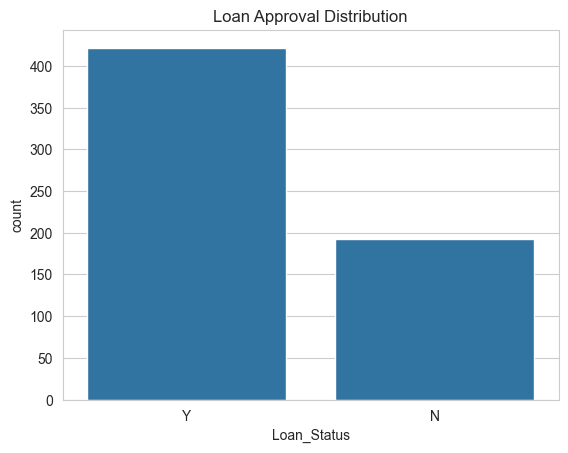

In [17]:
sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Approval Distribution")
plt.show()

## Observations

- Dataset loaded successfully.
- The dataset contains both numerical and categorical variables.
- Missing values are present.
- Target variable is Loan_Status.
- Class distribution will be examined before model building.

# Exploratory Data Analysis (EDA)

## Objective

Exploratory Data Analysis (EDA) is performed to understand the characteristics of the dataset before preprocessing and model building.

In this section, we will:

- Analyze the target variable
- Study numerical features
- Study categorical features
- Detect outliers
- Understand feature relationships
- Draw business insights

## Target Variable Distribution

The first step is to understand the distribution of the target variable (Loan_Status).

This helps determine whether the dataset is balanced or imbalanced.

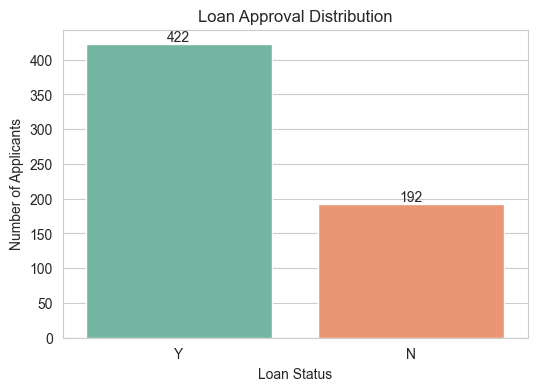

In [18]:
plt.figure(figsize=(6,4))

ax = sns.countplot(x='Loan_Status', data=df, palette='Set2')

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applicants")

# Add count labels
for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [19]:
(df['Loan_Status'].value_counts(normalize=True)*100).round(2)

Loan_Status
Y   68.73
N   31.27
Name: proportion, dtype: float64

### Observation

- Around **69%** of loan applications were approved.
- Around **31%** of applications were rejected.

### Business Insight

The dataset is moderately imbalanced.

Therefore, model performance should be evaluated using **Precision, Recall, F1-score, and ROC-AUC** instead of relying only on accuracy.

## Missing Value Analysis

Before preprocessing, it is important to identify which features contain missing values.

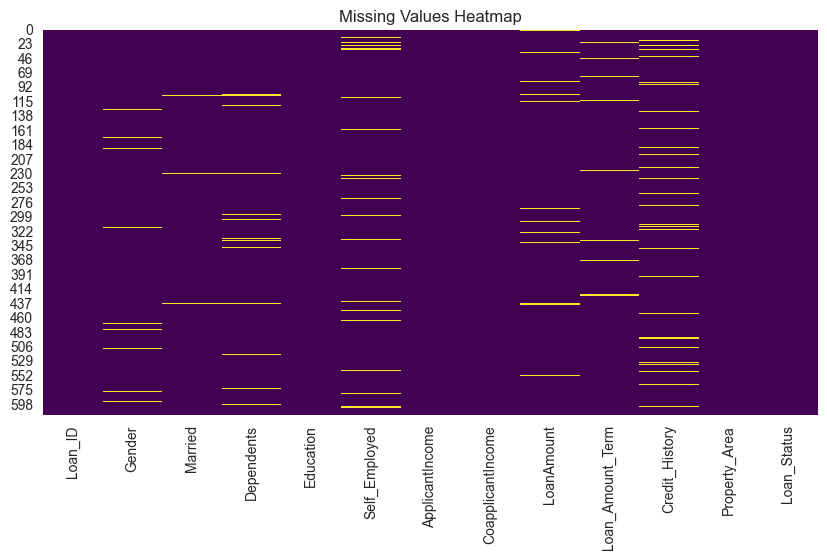

In [20]:
plt.figure(figsize=(10,5))

sns.heatmap(df.isnull(), cbar=False, cmap='viridis')

plt.title("Missing Values Heatmap")

plt.show()

### Observation

Missing values are present in multiple columns, particularly:

- Credit_History
- Self_Employed
- LoanAmount
- Loan_Amount_Term
- Dependents
- Gender

### Business Insight

Appropriate imputation techniques will be applied during preprocessing instead of dropping valuable records.

## Distribution of Numerical Features

Understanding the distribution of numerical variables helps identify skewness and unusual patterns.

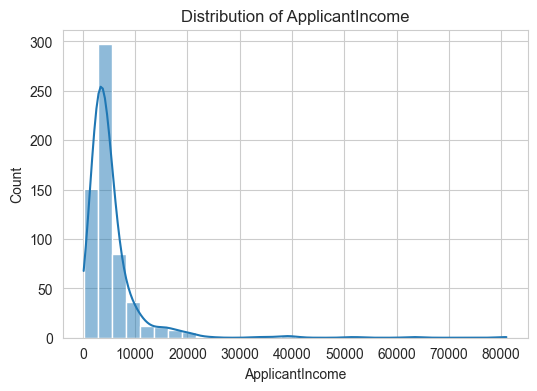

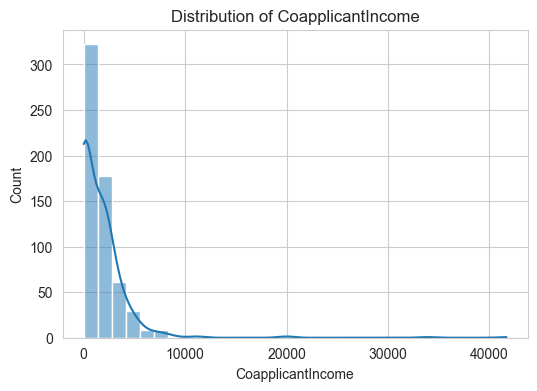

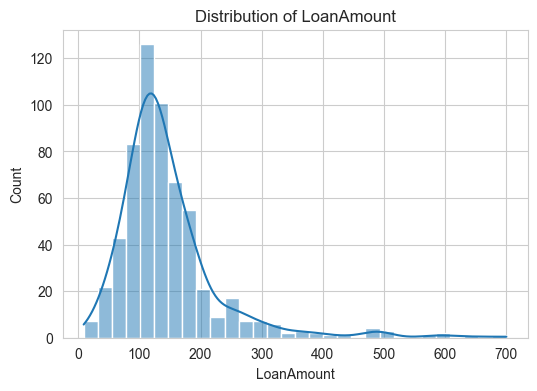

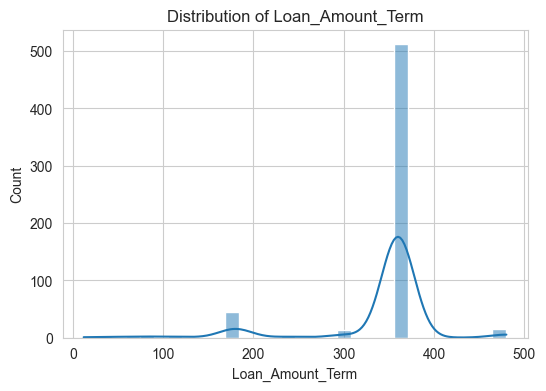

In [21]:
num_cols = [
    'ApplicantIncome',
    'CoapplicantIncome',
    'LoanAmount',
    'Loan_Amount_Term'
]

for col in num_cols:

    plt.figure(figsize=(6,4))

    sns.histplot(df[col], kde=True, bins=30)

    plt.title(f'Distribution of {col}')

    plt.show()

### Observation

Income-related features appear positively skewed.

### Business Insight

Highly skewed income distributions may require transformation during preprocessing if needed.

## Outlier Detection

Boxplots help identify extreme values in numerical variables.

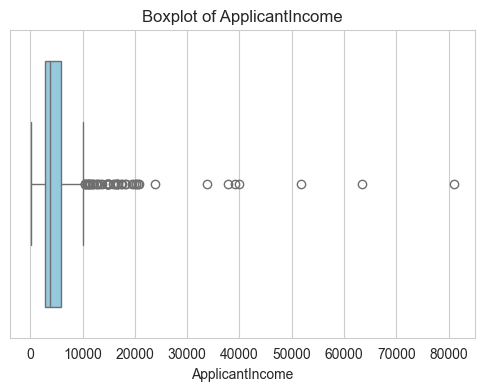

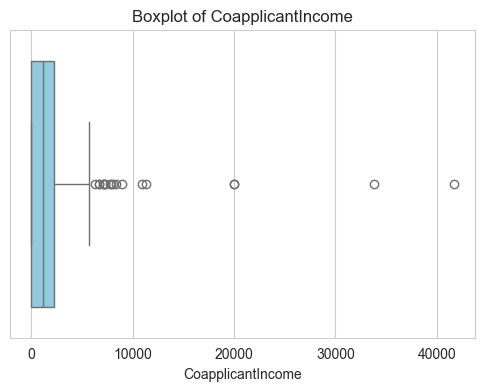

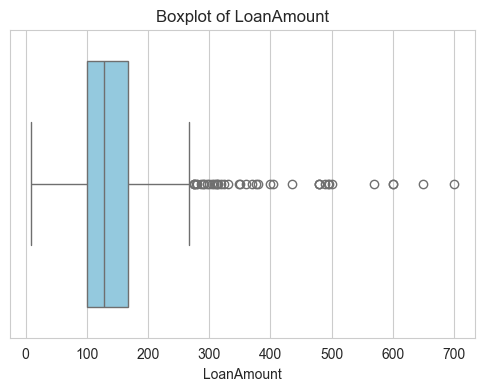

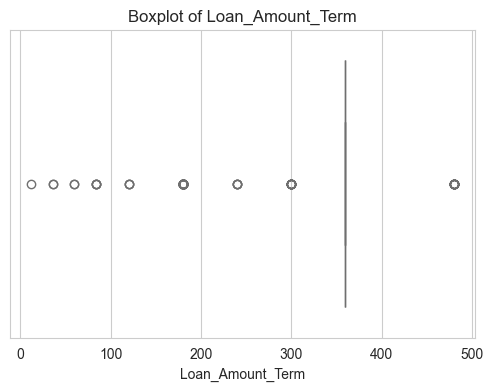

In [22]:
for col in num_cols:

    plt.figure(figsize=(6,4))

    sns.boxplot(x=df[col], color='skyblue')

    plt.title(f'Boxplot of {col}')

    plt.show()

### Observation

ApplicantIncome and LoanAmount contain several outliers.

### Business Insight

These outliers may represent genuine high-income applicants rather than data entry errors.

Therefore, they should be handled carefully instead of removing them blindly.

## Distribution of Categorical Features

This analysis helps understand applicant demographics and other categorical variables.

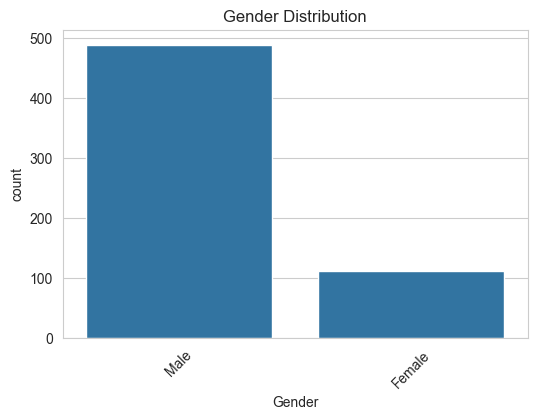

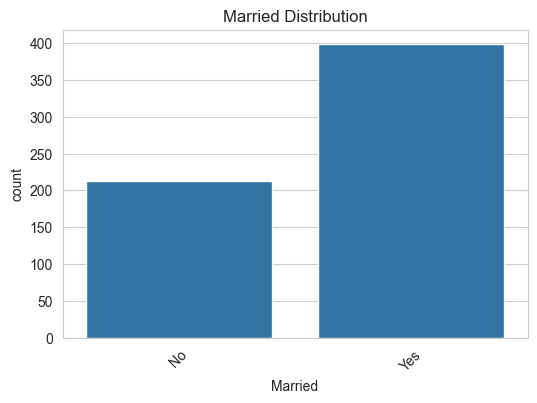

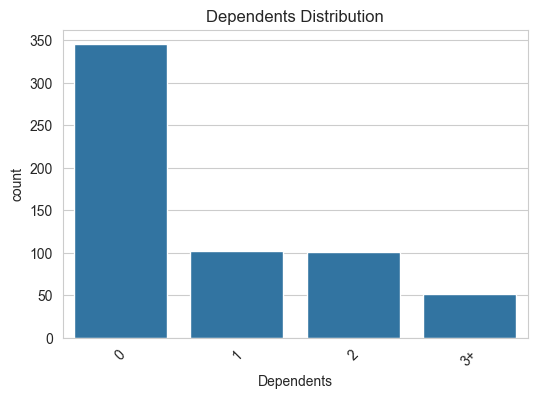

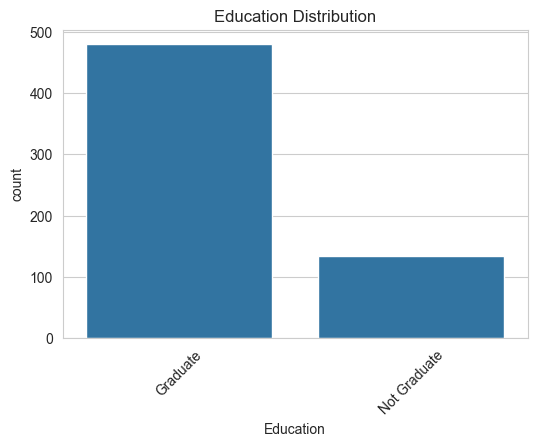

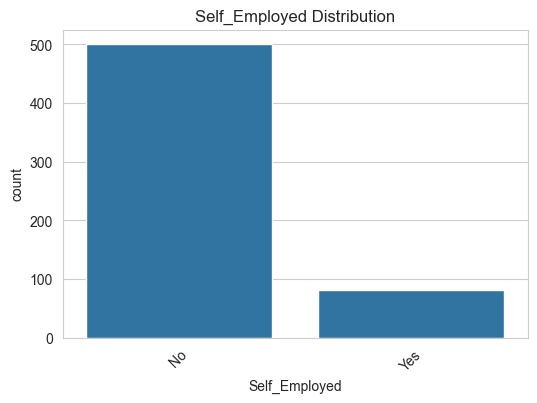

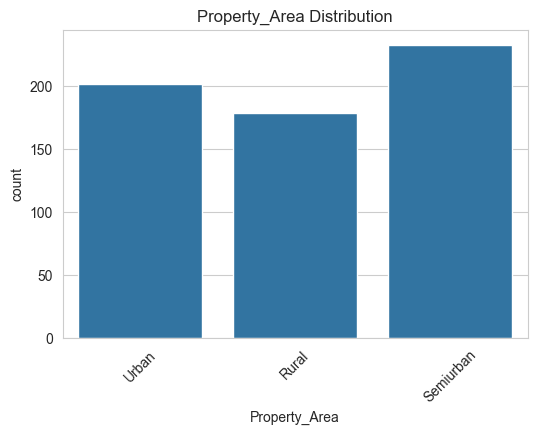

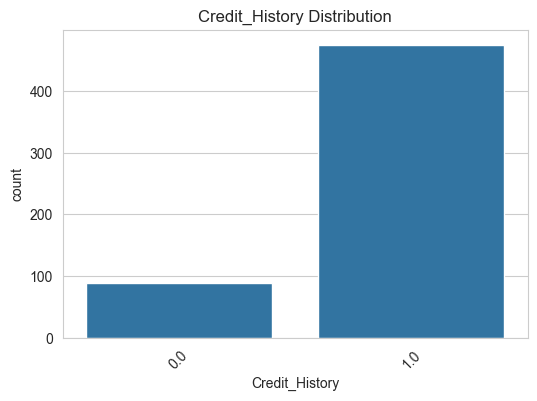

In [23]:
cat_cols = [
    'Gender',
    'Married',
    'Dependents',
    'Education',
    'Self_Employed',
    'Property_Area',
    'Credit_History'
]

for col in cat_cols:

    plt.figure(figsize=(6,4))

    sns.countplot(x=col, data=df)

    plt.title(f'{col} Distribution')

    plt.xticks(rotation=45)

    plt.show()

## Correlation Analysis

Correlation helps identify relationships between numerical variables.

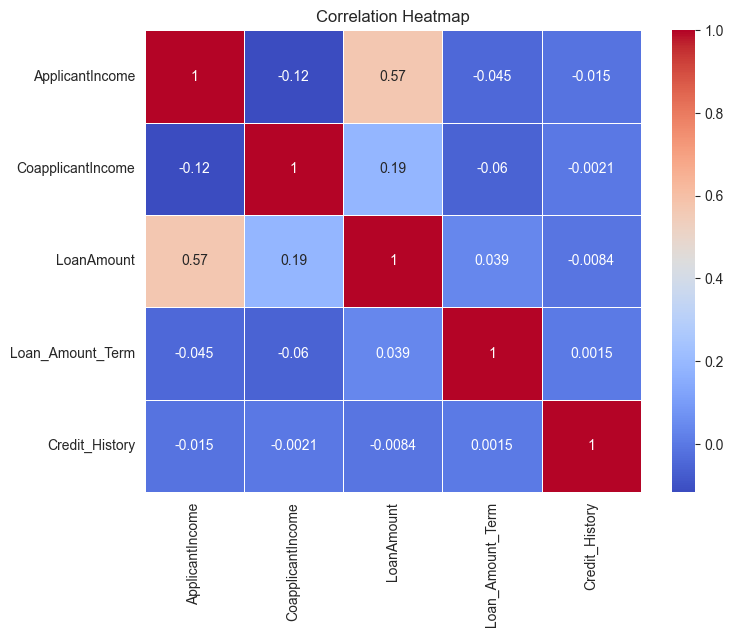

In [24]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

Most numerical variables show weak correlations.

### Business Insight

This indicates that multiple independent factors contribute to loan approval decisions.

# Relationship Between Features and Loan Approval

This section examines how different applicant characteristics influence loan approval.

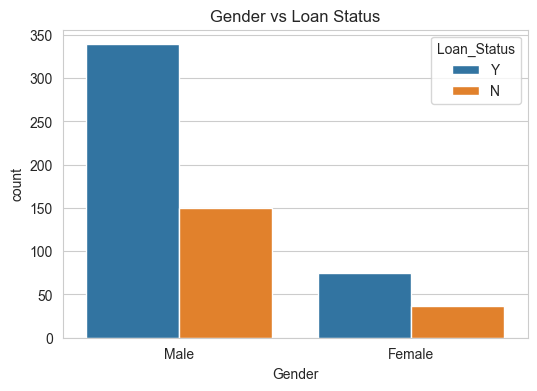

In [25]:
plt.figure(figsize=(6,4))

sns.countplot(x='Gender', hue='Loan_Status', data=df)

plt.title("Gender vs Loan Status")

plt.show()

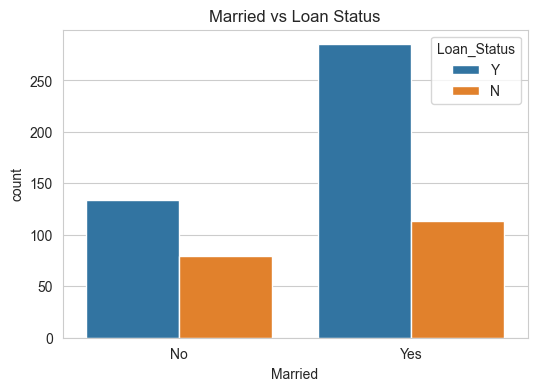

In [26]:
plt.figure(figsize=(6,4))

sns.countplot(x='Married', hue='Loan_Status', data=df)

plt.title("Married vs Loan Status")

plt.show()

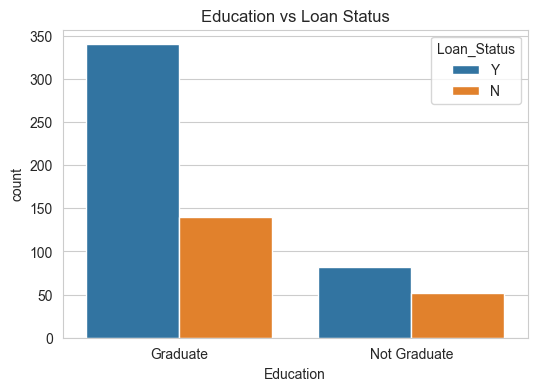

In [27]:
plt.figure(figsize=(6,4))

sns.countplot(x='Education', hue='Loan_Status', data=df)

plt.title("Education vs Loan Status")

plt.show()

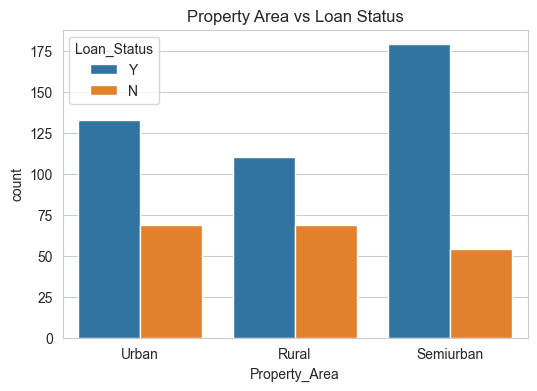

In [28]:
plt.figure(figsize=(6,4))

sns.countplot(x='Property_Area', hue='Loan_Status', data=df)

plt.title("Property Area vs Loan Status")

plt.show()

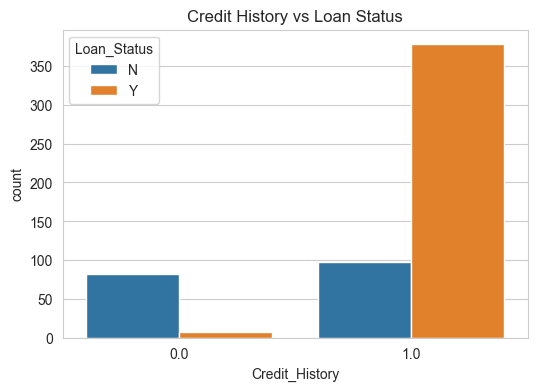

In [29]:
plt.figure(figsize=(6,4))

sns.countplot(x='Credit_History', hue='Loan_Status', data=df)

plt.title("Credit History vs Loan Status")

plt.show()

### Key Business Insight

Applicants with a positive credit history are significantly more likely to receive loan approval.

Credit history appears to be one of the strongest predictors for loan approval.

# Summary of EDA

### Key Findings

- The dataset is moderately imbalanced.
- Missing values exist in several features.
- ApplicantIncome and LoanAmount contain outliers.
- Income variables are positively skewed.
- Credit History appears to be the most influential feature.
- No severe multicollinearity exists among numerical variables.

These findings will guide the preprocessing and model-building stages.

# Drop Unnecessary Features

The `Loan_ID` column is a unique identifier assigned to each loan application.

Since it does not provide any predictive information, it is removed before model training.

In [30]:
df.drop("Loan_ID", axis=1, inplace=True)

df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.00,NaN,360.00,1.00,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.00,128.00,360.00,1.00,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.00,66.00,360.00,1.00,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.00,120.00,360.00,1.00,Urban,Y
4,Male,No,0,Graduate,No,6000,0.00,141.00,360.00,1.00,Urban,Y


# Missing Value Analysis

Before imputing missing values, we verify the number of missing observations in each feature.

In [31]:
df.isnull().sum()

Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

# Separate Numerical and Categorical Features

Separating numerical and categorical features helps us apply different preprocessing techniques.

In [32]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include='object').columns

print("Numerical Features:")
print(list(num_cols))

print("\nCategorical Features:")
print(list(cat_cols))

Numerical Features:
['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

Categorical Features:
['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']


# Missing Value Imputation

Different imputation strategies are used depending on the nature of the feature.

- Categorical Features → Mode
- LoanAmount → Median (robust to outliers)
- Credit_History → Mode

In [33]:
# Fill Missing Values

# Categorical Columns
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

df['Married'] = df['Married'].fillna(df['Married'].mode()[0])

df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])

df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

# Numerical Column
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

# Loan Amount Term
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])

# Credit History
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

# Verify Missing Values

After imputation, we ensure that no missing values remain.

In [34]:
df.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             614 non-null    object 
 1   Married            614 non-null    object 
 2   Dependents         614 non-null    object 
 3   Education          614 non-null    object 
 4   Self_Employed      614 non-null    object 
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         614 non-null    float64
 8   Loan_Amount_Term   614 non-null    float64
 9   Credit_History     614 non-null    float64
 10  Property_Area      614 non-null    object 
 11  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 62.4+ KB


# Preprocessing Summary

The preprocessing stage involved:

- Removing the Loan_ID column.
- Handling missing values using appropriate imputation techniques.
- Preserving all observations without dropping rows.
- Preparing the dataset for encoding and model training.

The dataset is now free of missing values and ready for categorical encoding.

# Feature Selection

Before training the machine learning model, we separate the independent features (X) and the target variable (y).

- X contains applicant information.
- y contains the loan approval status.

In [36]:
# Independent Features
X = df.drop("Loan_Status", axis=1)

# Target Variable
y = df["Loan_Status"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (614, 11)
Target Shape : (614,)


# Target Encoding

The target variable is encoded into numerical values.

- Approved (Y) → 1
- Rejected (N) → 0

In [37]:
y = y.map({'Y':1,'N':0})

y.value_counts()

Loan_Status
1    422
0    192
Name: count, dtype: int64

# Train-Test Split

The dataset is divided into training and testing sets.

- Training Data → 80%
- Testing Data → 20%

The random_state parameter ensures reproducibility.

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [39]:
print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)

print()

print("Training Target :", y_train.shape)
print("Testing Target :", y_test.shape)

Training Features : (491, 11)
Testing Features : (123, 11)

Training Target : (491,)
Testing Target : (123,)


In [40]:
categorical_features = X_train.select_dtypes(include='object').columns

numerical_features = X_train.select_dtypes(exclude='object').columns

print(categorical_features)

print()

print(numerical_features)

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area'],
      dtype='object')

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')


# Feature Encoding

Machine learning algorithms require numerical input.

The categorical variables are transformed into numerical representations using **One-Hot Encoding**.

One-Hot Encoding avoids introducing artificial ordering among categories and is suitable for nominal features.

In [41]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Identify categorical and numerical columns
categorical_features = X_train.select_dtypes(include='object').columns
numerical_features = X_train.select_dtypes(exclude='object').columns

# Create Column Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

# Fit on training data and transform both datasets
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("Encoded Training Shape :", X_train_encoded.shape)
print("Encoded Testing Shape :", X_test_encoded.shape)

Encoded Training Shape : (491, 20)
Encoded Testing Shape : (123, 20)


# Feature Scaling

Feature scaling is performed using StandardScaler.

Scaling ensures that numerical features have comparable ranges, which benefits distance-based algorithms and improves the effectiveness of SMOTE.

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler(with_mean=False)

X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print("Scaling Completed Successfully!")

Scaling Completed Successfully!


# Handling Class Imbalance

The training dataset is imbalanced.

To address this issue, **SMOTE (Synthetic Minority Over-sampling Technique)** is applied only to the training data.

Applying SMOTE only on training data prevents data leakage.

In [43]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

ModuleNotFoundError: No module named 'imblearn'

# Model Building

In this section, multiple machine learning classification models are trained and evaluated.

The objective is to compare their performance and identify the best model for predicting loan approval.

The following models will be trained:

- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
}

In [ ]:
results = []

for name, model in models.items():

    # Train
    model.fit(X_train_smote, y_train_smote)

    # Prediction
    y_pred = model.predict(X_test_scaled)

    # Probability
    y_prob = model.predict_proba(X_test_scaled)[:,1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    roc = roc_auc_score(y_test, y_prob)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc
    ])

In [ ]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
)

results_df.sort_values(
    by="F1 Score",
    ascending=False
)

## Model Comparison

The models are compared using multiple evaluation metrics rather than relying only on accuracy.

The model with the highest F1-score and ROC-AUC will be considered the best candidate for deployment.

In [ ]:
best_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

best_model.fit(X_train_smote, y_train_smote)

y_pred = best_model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")

plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    best_model,
    X_test_scaled,
    y_test
)

plt.show()

# Model Evaluation Summary

The models were evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Since the dataset is moderately imbalanced, greater importance is given to **F1-score** and **ROC-AUC** when selecting the final model.

## Model Evaluation

Three classification models were trained and compared.

Among all models, **Logistic Regression achieved the highest overall performance**, with an F1-score of **0.89** and ROC-AUC of **0.87**.

Therefore, Logistic Regression was selected as the final model for deployment.

In [ ]:
feature_names = preprocessor.get_feature_names_out()

importances = best_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()

# Final Model Selection

Three machine learning models were trained and evaluated.

Based on Accuracy, Precision, Recall, F1-score, and ROC-AUC, **Logistic Regression** achieved the best overall performance.

Therefore, Logistic Regression is selected as the final model for deployment.

In [ ]:
best_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

best_model.fit(X_train_smote, y_train_smote)

y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:,1]

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [ ]:
print(classification_report(y_test,y_pred))

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    best_model,
    X_test_scaled,
    y_test
)

plt.title("ROC Curve - Logistic Regression")

plt.show()

In [ ]:
feature_names = preprocessor.get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": best_model.coef_[0]
})

importance["Absolute"] = importance["Coefficient"].abs()

importance = importance.sort_values(
    by="Absolute",
    ascending=False
)

importance.head(10)

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Coefficient",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()

# Business Insights

The analysis of the loan approval dataset reveals several important insights:

- Applicants with a positive credit history have a significantly higher probability of loan approval.
- Higher applicant income generally increases the likelihood of approval.
- Larger loan amounts may slightly reduce approval chances due to increased lending risk.
- Property area and employment status also influence approval decisions.
- Logistic Regression performed best, indicating that the relationship between applicant characteristics and loan approval is relatively linear.

This model can assist banks in automating the initial loan screening process, reducing manual effort while maintaining consistent decision-making.

# Deployment Recommendation

The default probability threshold of **0.50** provides a good balance between precision and recall for this dataset.

However, financial institutions may increase the threshold to **0.60–0.70** if reducing false approvals is more important than approving more applicants.

The optimal threshold should be selected according to the bank's business objectives and risk tolerance.

# Conclusion

This project successfully developed a machine learning model to predict loan approval using applicant information.

The dataset was preprocessed by handling missing values, encoding categorical variables, scaling numerical features, and balancing the training data using SMOTE.

Three machine learning algorithms were evaluated:

- Logistic Regression
- Decision Tree
- Random Forest

Among them, Logistic Regression achieved the best performance based on F1-score and ROC-AUC.

The final model can support financial institutions by improving the efficiency and consistency of loan approval decisions.

# Future Work

Possible improvements include:

- Hyperparameter tuning using GridSearchCV.
- Evaluating advanced boosting algorithms such as XGBoost and LightGBM.
- Building an interactive web application using Streamlit or Flask.
- Monitoring model performance using real-world production data.

#End